# Day 62: Cross-Validation — K-Fold Deep Dive
**Phase 4 · Machine Learning** | Datasets: FC Lahore Lions matches and a red-card table (synthetic, seed = 42), plus sklearn's Iris

## Objective
By the end of this notebook I should be able to:
- Show why **one train/test split** gives an unreliable accuracy
- Explain and hand-code **K-Fold CV**: split into K folds, train on K-1, test on 1, rotate K times, average
- Use `cross_val_score(model, X, y, cv=5, scoring="accuracy")` and read **mean ± std** as a stability check
- Explain **Stratified K-Fold** and why it matters for imbalanced data
- Avoid the **sorted-data trap** (`shuffle=False` on ordered rows)

## Imports

In [1]:
# numpy and pandas for data
import numpy as np
import pandas as pd

# matplotlib for charts
import matplotlib.pyplot as plt

# models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# splitting and cross-validation tools
from sklearn.model_selection import (train_test_split, cross_val_score, KFold,
                                     StratifiedKFold, RepeatedStratifiedKFold)
from sklearn.datasets import load_iris

plt.rcParams["axes.grid"] = True

## Theory
- **Problem with a single split:** `train_test_split` puts a *random* 25% of rows in the test set. Change `random_state` and you get a different test set, so a different accuracy. Which one do you trust?
- **K-Fold CV:**
  1. Split the data into **K folds** (equal-sized parts).
  2. Train on K-1 folds, test on the 1 left out.
  3. Rotate so every fold is the test fold exactly once.
  4. Average the K scores.
- **`cross_val_score(model, X, y, cv=5, scoring="accuracy")`** does all of that and returns K scores. **Mean** = the estimate. **Std** = how stable it is.
- **Stratified K-Fold:** each fold keeps roughly the **same class proportions** as the full data. It matters when one class is rare, because a plain random fold can end up with very few (or zero) rare cases.
- **Good to know:** for classifiers, `cross_val_score(..., cv=5)` uses stratified folds by default (no shuffling).
- **Shuffle:** `KFold` without `shuffle=True` takes rows in their original order. If the rows are sorted (by class, by date), the folds are not a fair mix.
- **CV is for evaluating and choosing.** Keep a final test set for one last check (Day 57 pattern).

**Football picture:** judging a striker on one match is a gamble. He might score a hat-trick or get marked out. Judging him on 5 different matches and averaging is fairer, and the *spread* tells you if he is consistent or streaky. Stratified folds make sure every match sample includes both big games and easy games in the same ratio.

## Example 1: The Problem with a Single Split

In [2]:
# Synthetic data: 500 matches (same dataset as Days 59 to 61)
rng = np.random.default_rng(42)                      # seed = 42 so results repeat
n_matches = 500

shots = rng.integers(0, 13, size=n_matches)          # shots on target
possession = rng.integers(35, 66, size=n_matches)    # possession %
pass_accuracy = rng.integers(70, 93, size=n_matches) # pass accuracy %
home_game = rng.integers(0, 2, size=n_matches)       # 1 = home, 0 = away
opponent_rank = rng.integers(1, 21, size=n_matches)  # 1 = strongest opponent
kickoff_hour = rng.integers(12, 22, size=n_matches)  # NOT linked to the result, on purpose

z = (0.45 * shots + 0.04 * (possession - 50) + 0.7 * home_game
     + 0.10 * (opponent_rank - 10) - 3.0)
won = rng.binomial(1, 1 / (1 + np.exp(-z)))

df = pd.DataFrame({
    "match_id": np.arange(1, n_matches + 1),
    "shots_on_target": shots, "possession_pct": possession,
    "pass_accuracy_pct": pass_accuracy, "home_game": home_game,
    "opponent_rank": opponent_rank, "kickoff_hour": kickoff_hour, "won": won
})

# Save next to the notebook, then read it back
df.to_csv("day_62_fc_lahore_lions_matches.csv", index=False)
df = pd.read_csv("day_62_fc_lahore_lions_matches.csv")

X = df.drop(columns=["match_id", "won"])
y = df["won"]
print(X.shape, "| win rate:", round(y.mean(), 3))

(500, 6) | win rate: 0.502


In [3]:
# SAME model, SAME data. Only the random split changes (100 different random_state values).
single_split_acc = []
for split_seed in range(100):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.25, random_state=split_seed, stratify=y
    )
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_tr, y_tr)
    single_split_acc.append(model.score(X_te, y_te))

single_split_acc = np.array(single_split_acc)
print("Lowest test accuracy: ", round(single_split_acc.min(), 3))
print("Highest test accuracy:", round(single_split_acc.max(), 3))
print("Mean:", round(single_split_acc.mean(), 3), "| Std:", round(single_split_acc.std(), 3))

Lowest test accuracy:  0.68
Highest test accuracy: 0.856
Mean: 0.765 | Std: 0.038


## Example 2: K-Fold CV by Hand, then with cross_val_score

### 2A. What the folds look like

In [4]:
# 5 folds, shuffled first so the rows are mixed
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold_no, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    print("Fold", fold_no, "| train rows:", len(train_idx), "| test rows:", len(test_idx))

# Every row should be a test row exactly once
times_tested = np.zeros(len(X), dtype=int)
for _, test_idx in kf.split(X):
    times_tested[test_idx] += 1
print("\nEvery row tested exactly once:", bool((times_tested == 1).all()))

Fold 1 | train rows: 400 | test rows: 100
Fold 2 | train rows: 400 | test rows: 100
Fold 3 | train rows: 400 | test rows: 100
Fold 4 | train rows: 400 | test rows: 100
Fold 5 | train rows: 400 | test rows: 100

Every row tested exactly once: True


### 2B. Hand-coded loop = cross_val_score

In [5]:
# The manual version: train on K-1 folds, test on the left-out fold, rotate
rf = RandomForestClassifier(n_estimators=100, random_state=42)
manual_scores = []
for train_idx, test_idx in kf.split(X):
    rf.fit(X.iloc[train_idx], y.iloc[train_idx])                    # train on 4 folds
    manual_scores.append(rf.score(X.iloc[test_idx], y.iloc[test_idx]))  # test on the 5th

print("Manual fold scores:", np.round(manual_scores, 3))
print("Mean:", round(np.mean(manual_scores), 3))

Manual fold scores: [0.85 0.71 0.8  0.78 0.76]
Mean: 0.78


In [6]:
# The one-line version gives the same numbers
cv_scores = cross_val_score(rf, X, y, cv=kf, scoring="accuracy")

print("cross_val_score:", cv_scores.round(3))
print("Same as manual loop:", np.allclose(cv_scores, manual_scores))
print("\nMean +/- std:", round(cv_scores.mean(), 3), "+/-", round(cv_scores.std(), 3))

cross_val_score: [0.85 0.71 0.8  0.78 0.76]
Same as manual loop: True

Mean +/- std: 0.78 +/- 0.046


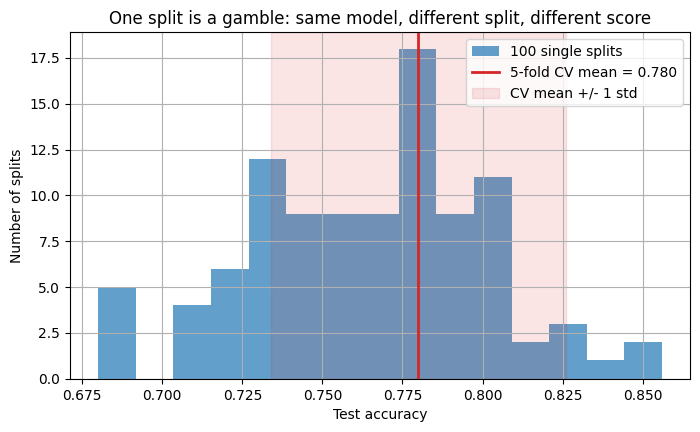

In [7]:
# Chart: the 100 single-split accuracies vs the 5-fold CV estimate
plt.figure(figsize=(8, 4.5))
plt.hist(single_split_acc, bins=15, color="tab:blue", alpha=0.7, label="100 single splits")
plt.axvline(cv_scores.mean(), color="tab:red", linewidth=2,
            label=f"5-fold CV mean = {cv_scores.mean():.3f}")
plt.axvspan(cv_scores.mean() - cv_scores.std(), cv_scores.mean() + cv_scores.std(),
            color="tab:red", alpha=0.12, label="CV mean +/- 1 std")
plt.xlabel("Test accuracy")
plt.ylabel("Number of splits")
plt.title("One split is a gamble: same model, different split, different score")
plt.legend()
plt.savefig("images/single_split_accuracy_spread.png", dpi=150, bbox_inches="tight")
plt.show()

### 2C. How many folds? K = 3, 5, 10

In [8]:
# More folds = more training rows per fit, smaller test folds, more fits
fold_results = {}
print("  K | mean  | std   | fits")
for k in [3, 5, 10]:
    kf_k = KFold(n_splits=k, shuffle=True, random_state=42)
    s = cross_val_score(rf, X, y, cv=kf_k)
    fold_results[k] = s
    print(f"{k:>3} | {s.mean():.3f} | {s.std():.3f} | {k}")

  K | mean  | std   | fits


  3 | 0.774 | 0.037 | 3


  5 | 0.780 | 0.046 | 5


 10 | 0.770 | 0.071 | 10


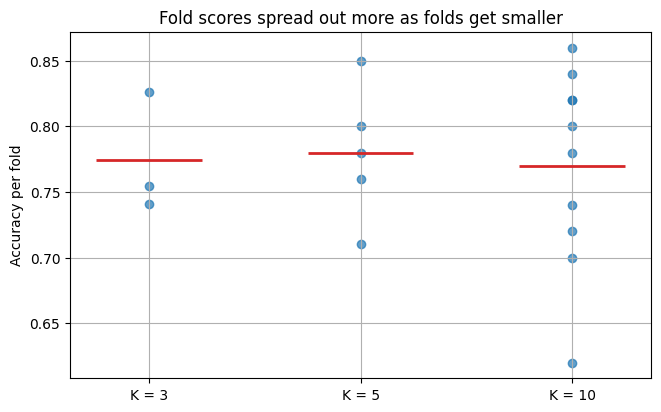

In [9]:
# Chart: every fold score for K = 3, 5, 10 (dots) with the mean (red line)
plt.figure(figsize=(7.5, 4.5))
for pos, k in enumerate([3, 5, 10]):
    scores = fold_results[k]
    plt.scatter([pos] * len(scores), scores, color="tab:blue", alpha=0.7)
    plt.hlines(scores.mean(), pos - 0.25, pos + 0.25, color="tab:red", linewidth=2)
plt.xticks([0, 1, 2], ["K = 3", "K = 5", "K = 10"])
plt.ylabel("Accuracy per fold")
plt.title("Fold scores spread out more as folds get smaller")
plt.savefig("images/cv_fold_scores_by_k.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# What does cv=5 do by itself? For classifiers it means STRATIFIED folds, NOT shuffled.
default_scores = cross_val_score(rf, X, y, cv=5)
print("cv=5 default:", default_scores.round(3), "| mean:", round(default_scores.mean(), 3))
print("KFold shuffled:", cv_scores.round(3), "| mean:", round(cv_scores.mean(), 3))
# Different folds, so different fold scores. The means are close.

cv=5 default: [0.79 0.77 0.72 0.79 0.8 ] | mean: 0.774
KFold shuffled: [0.85 0.71 0.8  0.78 0.76] | mean: 0.78


## Example 3: The Sorted-Data Trap (shuffle)

In [11]:
# The Iris dataset is sorted by class: 50 setosa, then 50 versicolor, then 50 virginica
X_iris, y_iris = load_iris(return_X_y=True)
print("First, middle and last labels:", y_iris[0], y_iris[75], y_iris[149])

plain = KFold(n_splits=3)                                    # no shuffle
for fold_no, (_, test_idx) in enumerate(plain.split(X_iris), start=1):
    print("Plain KFold, fold", fold_no, "test class counts:", np.bincount(y_iris[test_idx], minlength=3))

First, middle and last labels: 0 1 2
Plain KFold, fold 1 test class counts: [50  0  0]
Plain KFold, fold 2 test class counts: [ 0 50  0]
Plain KFold, fold 3 test class counts: [ 0  0 50]


In [12]:
# Each test fold is a class the model NEVER saw in training, so it cannot get any right
lr = LogisticRegression(max_iter=1000)

plain_scores = cross_val_score(lr, X_iris, y_iris, cv=KFold(n_splits=3))
shuffled_scores = cross_val_score(lr, X_iris, y_iris, cv=KFold(n_splits=3, shuffle=True, random_state=42))
strat_scores = cross_val_score(lr, X_iris, y_iris, cv=3)          # default = stratified

print("Plain KFold (no shuffle):", plain_scores.round(2))
print("KFold shuffle=True:      ", shuffled_scores.round(2))
print("Default cv=3 (stratified):", strat_scores.round(2))

Plain KFold (no shuffle): [0. 0. 0.]
KFold shuffle=True:       [1.   0.92 0.98]
Default cv=3 (stratified): [0.98 0.96 0.98]


## Example 4: Stratified K-Fold on Imbalanced Data

In [13]:
# A rarer event: red cards. 200 matches, only a small share have a red card.
rng2 = np.random.default_rng(42)
n2 = 200
fouls = rng2.poisson(11, n2)                 # fouls committed
yellows = rng2.poisson(1.8, n2)              # yellow cards
opp_rank = rng2.integers(1, 21, n2)          # opponent rank
derby = rng2.integers(0, 2, n2)              # 1 = derby match

z2 = 0.25 * (fouls - 11) + 0.35 * (yellows - 1.8) + 0.8 * derby - 2.9
red_card = rng2.binomial(1, 1 / (1 + np.exp(-z2)))

red_df = pd.DataFrame({
    "match_id": np.arange(1, n2 + 1), "fouls_committed": fouls, "yellow_cards": yellows,
    "opponent_rank": opp_rank, "derby_match": derby, "red_card": red_card
})
red_df.to_csv("day_62_fc_lahore_lions_red_cards.csv", index=False)
red_df = pd.read_csv("day_62_fc_lahore_lions_red_cards.csv")

X2 = red_df.drop(columns=["match_id", "red_card"])
y2 = red_df["red_card"]
print("Red-card matches:", int(y2.sum()), "of", len(y2), "| share:", round(y2.mean(), 3))
print("Accuracy of always predicting 'no red card':", round(1 - y2.mean(), 3))

Red-card matches: 28 of 200 | share: 0.14
Accuracy of always predicting 'no red card': 0.86


In [14]:
# How many red-card matches land in each TEST fold? (10 folds)
kf10 = KFold(n_splits=10, shuffle=True, random_state=42)
skf10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

pos_kfold = [int(y2.iloc[te].sum()) for _, te in kf10.split(X2, y2)]
pos_strat = [int(y2.iloc[te].sum()) for _, te in skf10.split(X2, y2)]

print("Plain KFold red cards per fold:  ", pos_kfold)
print("Stratified red cards per fold:   ", pos_strat)

Plain KFold red cards per fold:   [5, 3, 1, 7, 1, 3, 1, 2, 1, 4]
Stratified red cards per fold:    [2, 2, 3, 3, 3, 3, 3, 3, 3, 3]


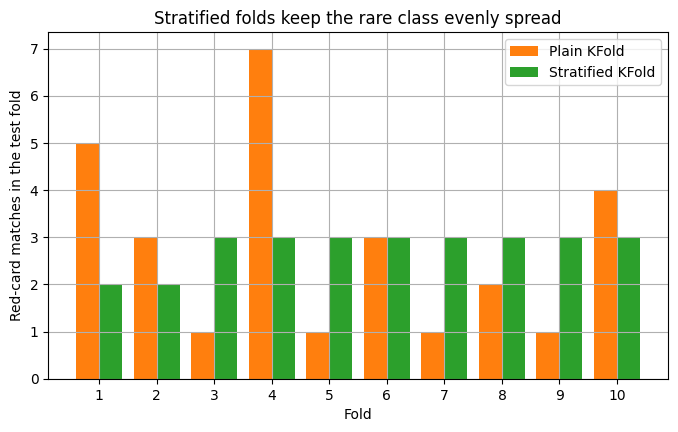

In [15]:
# Chart: red-card matches per test fold, plain vs stratified
fold_labels = np.arange(1, 11)
plt.figure(figsize=(8, 4.5))
plt.bar(fold_labels - 0.2, pos_kfold, width=0.4, label="Plain KFold", color="tab:orange")
plt.bar(fold_labels + 0.2, pos_strat, width=0.4, label="Stratified KFold", color="tab:green")
plt.xticks(fold_labels)
plt.xlabel("Fold")
plt.ylabel("Red-card matches in the test fold")
plt.title("Stratified folds keep the rare class evenly spread")
plt.legend()
plt.savefig("images/stratified_fold_composition.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
# Score both fold types. Accuracy is a poor guide here (Day 55), so use recall and F1.
# class_weight="balanced" makes the model pay more attention to the rare class.
lr_red = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced"))

for name, cv in [("Plain KFold", kf10), ("Stratified", skf10)]:
    rec = cross_val_score(lr_red, X2, y2, cv=cv, scoring="recall")
    f1 = cross_val_score(lr_red, X2, y2, cv=cv, scoring="f1")
    print(name)
    print("  recall per fold:", rec.round(2))
    print("  recall mean +/- std:", round(rec.mean(), 3), "+/-", round(rec.std(), 3))
    print("  F1 mean +/- std:    ", round(f1.mean(), 3), "+/-", round(f1.std(), 3))

Plain KFold
  recall per fold: [0.6  0.33 0.   0.71 1.   1.   1.   0.   1.   0.75]
  recall mean +/- std: 0.64 +/- 0.381
  F1 mean +/- std:     0.302 +/- 0.195
Stratified
  recall per fold: [1.   0.5  0.67 1.   0.67 1.   0.67 0.33 0.67 0.33]
  recall mean +/- std: 0.683 +/- 0.241
  F1 mean +/- std:     0.361 +/- 0.144


In [17]:
# Does stratifying change the OVERALL estimate? Repeat 5-fold F1 with 30 different shuffles.
plain_means, strat_means = [], []
for seed in range(30):
    plain_means.append(cross_val_score(lr_red, X2, y2, scoring="f1",
                                       cv=KFold(5, shuffle=True, random_state=seed)).mean())
    strat_means.append(cross_val_score(lr_red, X2, y2, scoring="f1",
                                       cv=StratifiedKFold(5, shuffle=True, random_state=seed)).mean())

print("Plain KFold:  mean of CV means", round(np.mean(plain_means), 3), "| std", round(np.std(plain_means), 3))
print("Stratified:   mean of CV means", round(np.mean(strat_means), 3), "| std", round(np.std(strat_means), 3))
# On this small dataset the overall estimate barely changes. Stratifying mainly makes
# each fold usable, and it matters more as the rare class gets rarer.

Plain KFold:  mean of CV means 0.324 | std 0.027
Stratified:   mean of CV means 0.324 | std 0.025


## Practice Exercise
**Your turn (Practice).** On the red-card data (`X2`, `y2`) with the `lr_red` pipeline:
1. Build `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`.
2. Run `cross_val_score` with `scoring="f1"`.
3. Report the fold scores and the mean ± std.
4. How many red-card matches are in each test fold?

In [18]:
# Your attempt here

In [19]:
# Worked answer
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scores = cross_val_score(lr_red, X2, y2, cv=skf5, scoring="f1")

print("F1 per fold:", f1_scores.round(2))
print("Mean +/- std:", round(f1_scores.mean(), 3), "+/-", round(f1_scores.std(), 3))
print("Red cards per test fold:", [int(y2.iloc[te].sum()) for _, te in skf5.split(X2, y2)])

F1 per fold: [0.22 0.45 0.5  0.35 0.24]
Mean +/- std: 0.353 +/- 0.111
Red cards per test fold: [5, 5, 6, 6, 6]


## Mini Challenge
**Repeated CV.** One 5-fold run still depends on how the rows were shuffled. Use `RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)` on the 500-match data with the random forest, so you get 50 scores.
1. Report the mean ± std of all 50 scores.
2. Reshape into 10 repeats x 5 folds, take each repeat's mean, and report how much those 10 means vary.
3. Compare with the single 5-fold run from Example 2.

In [20]:
# Mini Challenge solution
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
rep_scores = cross_val_score(rf, X, y, cv=rskf, scoring="accuracy")

print("Number of scores:", len(rep_scores))
print("All 50 scores: mean", round(rep_scores.mean(), 3), "| std", round(rep_scores.std(), 3))

per_repeat_means = rep_scores.reshape(10, 5).mean(axis=1)
print("10 repeat means:", per_repeat_means.round(3))
print("Spread of the repeat means (std):", round(per_repeat_means.std(), 3))

print("\nSingle 5-fold run from Example 2:", round(cv_scores.mean(), 3), "+/-", round(cv_scores.std(), 3))
# The single run (0.780) landed at the top of the range of repeat means. Repeating gives a steadier estimate.

Number of scores: 50
All 50 scores: mean 0.771 | std 0.027
10 repeat means: [0.78  0.774 0.776 0.768 0.774 0.758 0.772 0.77  0.762 0.778]
Spread of the repeat means (std): 0.007

Single 5-fold run from Example 2: 0.78 +/- 0.046


## Summary
- **One split is a gamble.** The same random forest scored anywhere from 0.680 to 0.856 on 100 different splits (mean 0.765, std 0.038).
- **K-Fold CV** trains on K-1 folds, tests on the left-out fold, rotates K times and averages. The hand-coded loop matched `cross_val_score` exactly.
- **Mean ± std:** 5-fold CV gave 0.780 ± 0.046. The std shows how much the score moves from fold to fold. With K = 10 the folds are smaller, so individual fold scores spread out more (std 0.071) while the mean stayed about the same.
- **Sorted data needs shuffling.** On Iris, plain `KFold(3)` scored 0.0 on every fold because each test fold was a class the model never saw. Shuffling or stratifying fixed it.
- **Stratified K-Fold** kept the rare red-card matches spread evenly (2 to 3 per test fold) versus 1 to 7 with plain KFold, and made the fold-level recall less erratic. The overall F1 estimate barely changed on this small dataset, so the real benefit is fold quality rather than a different average.
- **Repeated CV** (5 folds x 10 repeats = 50 scores) gave 0.771 with the 10 repeat means varying by only 0.007. The single 5-fold run (0.780) sat at the top of that range, a reminder that even one CV run depends on how the rows were shuffled.
- **Next: Day 63 — Hyperparameter tuning with GridSearchCV.**